In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Calculate Velocity Between Points

To calculate the velocity, we'll follow these steps:

1.  **Install the `haversine` library:** This library provides functions to calculate the distance between two points on a sphere (like Earth) given their latitude and longitude.
2.  **Calculate the Haversine distance:** For each point, we'll calculate the distance to the previous point using their `lat` and `lon` coordinates.
3.  **Calculate the time difference:** We'll determine the time elapsed between each consecutive pair of points using the `time` column.
4.  **Compute the velocity:** Velocity will be calculated as the distance divided by the time difference. The first point's velocity will be `NaN` as there is no preceding point.
5.  **Add a new `velocity` column:** The calculated velocities will be added as a new column to the `dflma` DataFrame.

In [ ]:
import sys
!{sys.executable} -m pip install haversine


Now that the `velocity` column has been added to the `dflma` DataFrame, you can include it as another feature for clustering. This allows the clustering algorithm to consider the movement dynamics of the points in addition to their altitude and power.

In [ ]:
lma_filename = '/content/drive/MyDrive/Mestrado LMA/DADOS LMA/LL_240720_234000_0600.dat/LL_240720_234000_0600.dat'

In [ ]:
hour = 23         #    <--- Insert whatever hour you want
min = 45          #    <--- Insert whatever minute you want
sec = 00   #    <--- Insert whatever second you want

#   Translate to 'seconds from midnight'
sfm_target_time = (hour*3600) + (min*60) + sec
#sfm_target_time = 85200.406334
sfm_target_time

85500

In [ ]:
dflma = pd.read_csv(
    lma_filename,
    sep=r'\s+',   # split by any whitespace, using raw string to fix SyntaxWarning
    header=None,             # no header row
    skiprows=55,             # skip first 55 rows
    names=['time','lat','lon','alt','chi','pw','hex']
)

display(dflma.describe())

# Operations moved from MRWnDXyxyTLz to ensure columns exist before filtering
# Convert the hexadecimal column to integer
dflma['hex_int'] = dflma['hex'].apply(lambda x: int(x, 16))

# Count how many '1' bits each hex number has
dflma['ns'] = dflma['hex_int'].apply(lambda x: bin(x).count('1'))
#display(dflma['time'])
#dflma['time'] = dflma['time'] - sfm_target_time # Subtract target time
#display(dflma['time'])
# Convert Altitude to km
dflma['alt'] = dflma['alt']/1000

#FILTERSSS

# Time Filter (removido para considerar todo o intervalo de tempo do arquivo inicialmente)
#dflma = dflma.query('time > 40')
#dflma = dflma.query('time < 41')

#Altitude filter
dflma = dflma.query('alt < 20')
dflma = dflma.query('alt > 0')

#Chi Filter
#dflma = dflma.query('chi < 0.4')

#Filter by power
#dflma = dflma.query('pw > 5')

#Number of stations Filter
#dflma = dflma.query('ns > 6')

,time,lat,lon,alt,chi,pw
count,564500.000000,564500.000000,564500.000000,5.645000e+05,564500.000000,564500.000000
mean,85495.073101,34.159102,-106.689837,7.337941e+04,1.380846,8.783772
std,173.588308,1.169487,1.664348,1.313823e+06,1.351418,9.093919
min,85199.999964,-32.338220,-168.382666,5.610000e+00,0.000000,-20.800000
25%,85343.374858,33.815713,-107.197612,9.637127e+03,0.270000,2.300000
50%,85490.774697,34.033160,-106.715227,1.648457e+04,0.900000,7.900000
75%,85645.773766,34.340749,-106.419839,6.776944e+04,2.190000,14.100000
max,85799.989220,87.372101,90.723444,8.577674e+08,5.000000,87.700000


In [ ]:

from haversine import haversine_vector, Unit

# Prepare coordinates for haversine calculation
coords = list(zip(dflma['lat'], dflma['lon']))

# Calculate distances between consecutive points
# The first distance will be NaN as there's no previous point
distances = [0] + haversine_vector(coords[:-1], coords[1:], unit=Unit.KILOMETERS).tolist()

# Calculate time differences between consecutive points
# The first time difference will be NaN
time_diffs = dflma['time'].diff().fillna(0).tolist()

# Calculate velocity (distance / time difference)
# Handle cases where time_diff is zero to avoid division by zero
velocity = []
for i in range(len(distances)):
    if time_diffs[i] != 0:
        velocity.append(distances[i] / abs(time_diffs[i]))
    else:
        velocity.append(0) # or np.nan, depending on desired behavior for zero time diff

# Add the velocity column to the DataFrame
dflma['velocity'] = velocity

print("Velocity calculated and added to 'dflma' DataFrame.")
display(dflma[['time', 'lat', 'lon', 'velocity']].head())

Velocity calculated and added to 'dflma' DataFrame.


,time,lat,lon,velocity
1,85200.073777,33.900260,-107.010915,0.000000e+00
9,85201.367647,34.022271,-107.429642,3.163516e+01
10,85201.367729,34.022132,-107.427251,2.671944e+03
11,85201.368255,34.016359,-107.409437,3.352643e+03
12,85201.368258,33.711629,-107.099341,1.485651e+07


In [ ]:
dflma.describe()

,time,lat,lon,alt,chi,pw,hex_int,ns,velocity
count,297544.000000,297544.000000,297544.000000,297544.000000,297544.000000,297544.000000,297544.000000,297544.000000,2.975440e+05
mean,85493.516451,34.035352,-106.796219,9.774843,1.270380,5.470307,8362.170230,5.717017,5.297151e+05
std,172.900439,0.411137,0.419875,3.377630,1.260426,7.219543,4120.065573,0.996043,1.806850e+07
min,85200.073777,30.796154,-111.521591,0.005610,0.000000,-20.800000,47.000000,5.000000,0.000000e+00
25%,85343.193015,33.823980,-107.183902,7.632103,0.280000,0.200000,5193.000000,5.000000,1.238864e+03
50%,85489.288592,34.010821,-106.699756,9.796985,0.820000,5.200000,8778.000000,5.000000,9.158561e+03
75%,85641.910535,34.193020,-106.553360,11.361023,1.910000,10.300000,12865.000000,6.000000,9.856237e+04
max,85799.949354,37.474853,-102.602704,19.999890,5.000000,53.400000,16375.000000,13.000000,5.323883e+09


adicionar o parâmetro de velocidade no cluster, o adonis passou qual algoritmo usar para calcular a velocidade de um ponto ao outro.


In [ ]:
from sklearn.preprocessing import StandardScaler

# Select the specified columns for clustering features, now including 'velocity'
features_for_clustering = dflma[['alt', 'pw', 'velocity']]

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit the scaler to the features and transform the data
scaled_features = scaler.fit_transform(features_for_clustering)

print("Selected features for clustering (including velocity):")
print(features_for_clustering.head())
print("\nScaled features (first 5 rows):")
print(scaled_features[:5])
print(f"Shape of scaled_features: {scaled_features.shape}")

Selected features for clustering (including velocity):
         alt    pw      velocity
1   19.41964  -0.7  0.000000e+00
9    8.30432   5.9  3.163516e+01
10   8.23890  -3.4  2.671944e+03
11   7.87748  11.7  3.352643e+03
12  10.59997   5.0  1.485651e+07

Scaled features (first 5 rows):
[[ 2.85549756 -0.85466869 -0.0293171 ]
 [-0.43537195  0.0595181  -0.02931535]
 [-0.45474059 -1.2286542  -0.02916922]
 [-0.5617448   0.86289437 -0.02913155]
 [ 0.24429221 -0.06514374  0.79291691]]
Shape of scaled_features: (297544, 3)


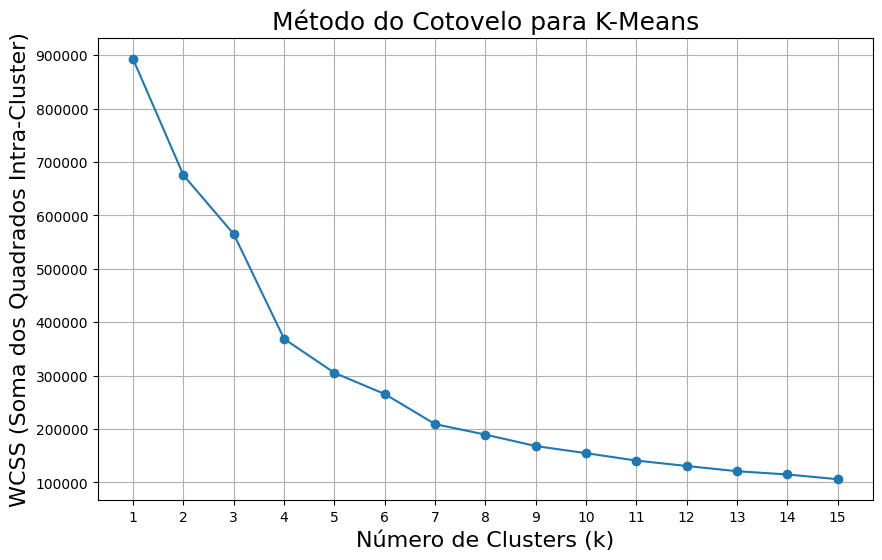

WCSS values calculated and Elbow Method plot displayed.


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

lblsize = 16 # Define lblsize as it was used in previous plotting cells
ticksize = 15 # Define ticksize for consistency, though not used in this specific plot

wcss = []
k_range = range(1, 16)  # Test k from 1 to 15

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto') # n_init='auto' to suppress warning
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method results
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='-')
plt.xlabel('Número de Clusters (k)', size=lblsize)
plt.ylabel('WCSS (Soma dos Quadrados Intra-Cluster)', size=lblsize)
plt.title('Método do Cotovelo para K-Means', size=lblsize + 2)
plt.xticks(k_range) # Ensure all k values are shown on x-axis
plt.grid(True)
plt.show()

print("WCSS values calculated and Elbow Method plot displayed.")

In [ ]:
from sklearn.cluster import KMeans

# Based on the elbow plot, let's choose k=4 as the optimal number of clusters.
k_optimal = 4

# Instantiate KMeans with the optimal number of clusters
kmeans_model = KMeans(n_clusters=k_optimal, random_state=42, n_init='auto')

# Fit the KMeans model to the scaled features
kmeans_model.fit(scaled_features)

# Get the cluster labels
cluster_labels = kmeans_model.labels_

# Add the cluster labels as a new column to the original dflma DataFrame
dflma['cluster'] = cluster_labels

print(f"K-Means clustering applied with k={k_optimal} clusters.")
print("First 5 rows of dflma with new 'cluster' column:")
print(dflma[['time', 'lat', 'lon', 'alt', 'pw', 'cluster']].head())

K-Means clustering applied with k=4 clusters.
First 5 rows of dflma with new 'cluster' column:
            time        lat         lon       alt    pw  cluster
1   85200.073777  33.900260 -107.010915  19.41964  -0.7        1
9   85201.367647  34.022271 -107.429642   8.30432   5.9        0
10  85201.367729  34.022132 -107.427251   8.23890  -3.4        0
11  85201.368255  34.016359 -107.409437   7.87748  11.7        2
12  85201.368258  33.711629 -107.099341  10.59997   5.0        1


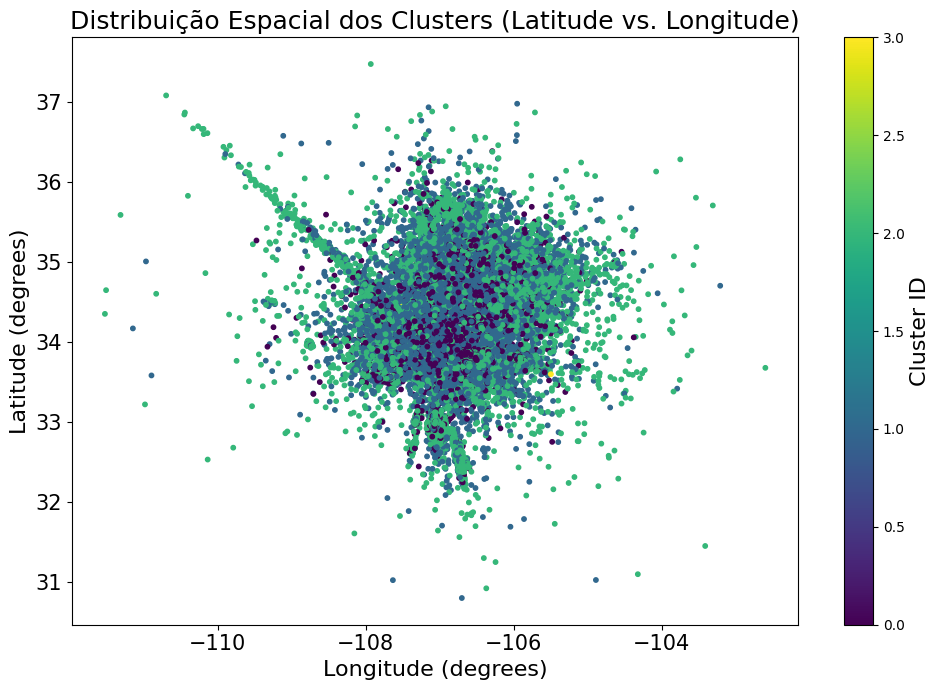

In [ ]:
import matplotlib.pyplot as plt

fig6, ax6 = plt.subplots(figsize=(10, 7))
scatter = ax6.scatter(dflma['lon'], dflma['lat'], c=dflma['cluster'], cmap='viridis', s=10)
ax6.set_xlabel("Longitude (degrees)", size=lblsize)
ax6.set_ylabel("Latitude (degrees)", size=lblsize)
ax6.set_title("Distribuição Espacial dos Clusters (Latitude vs. Longitude)", size=lblsize + 2)
ax6.tick_params(labelsize=ticksize)
cbar = fig6.colorbar(scatter, ax=ax6)
cbar.set_label('Cluster ID', size=lblsize)
plt.tight_layout()
plt.show()

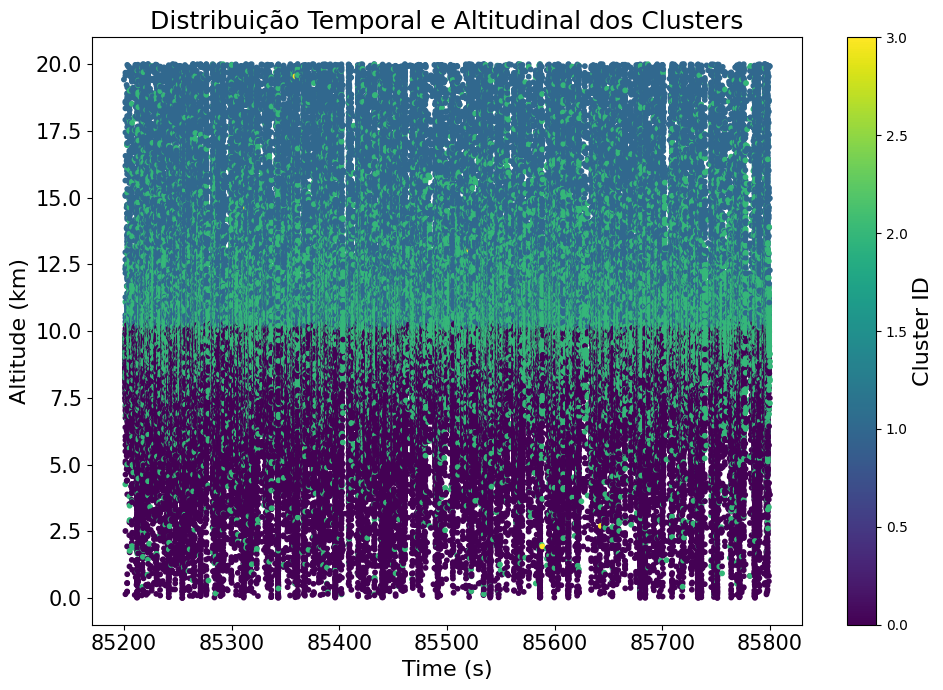

In [ ]:
fig7, ax7 = plt.subplots(figsize=(10, 7))
scatter = ax7.scatter(dflma['time'], dflma['alt'], c=dflma['cluster'], cmap='viridis', s=10)
ax7.set_xlabel("Time (s)", size=lblsize)
ax7.set_ylabel("Altitude (km)", size=lblsize)
ax7.set_title("Distribuição Temporal e Altitudinal dos Clusters", size=lblsize + 2)
ax7.tick_params(labelsize=ticksize)
cbar = fig7.colorbar(scatter, ax=ax7)
cbar.set_label('Cluster ID', size=lblsize)
plt.tight_layout()
plt.show()

In [ ]:
cluster_stats = dflma.groupby('cluster')[['alt', 'pw', 'velocity']].agg(['mean', 'min', 'max'])

print("Estatísticas descritivas para cada cluster:")
display(cluster_stats)

Estatísticas descritivas para cada cluster:


alt                            pw                  velocity  \
              mean      min       max       mean   min   max          mean   
cluster                                                                      
0         7.017595  0.00561  10.50732   1.092346 -20.8  17.7  3.120744e+05   
1        13.250650  9.81272  19.99989   1.845364 -19.2  17.4  5.867535e+05   
2        10.244496  0.12600  19.99547  12.702673   5.2  53.4  4.850302e+05   
3        10.447004  1.93910  19.54557   8.500000   1.0  17.6  2.531037e+09   

                                     
                  min           max  
cluster                              
0        3.036476e-01  9.081449e+08  
1        0.000000e+00  1.160758e+09  
2        4.352482e-01  1.005956e+09  
3        1.363845e+09  5.323883e+09

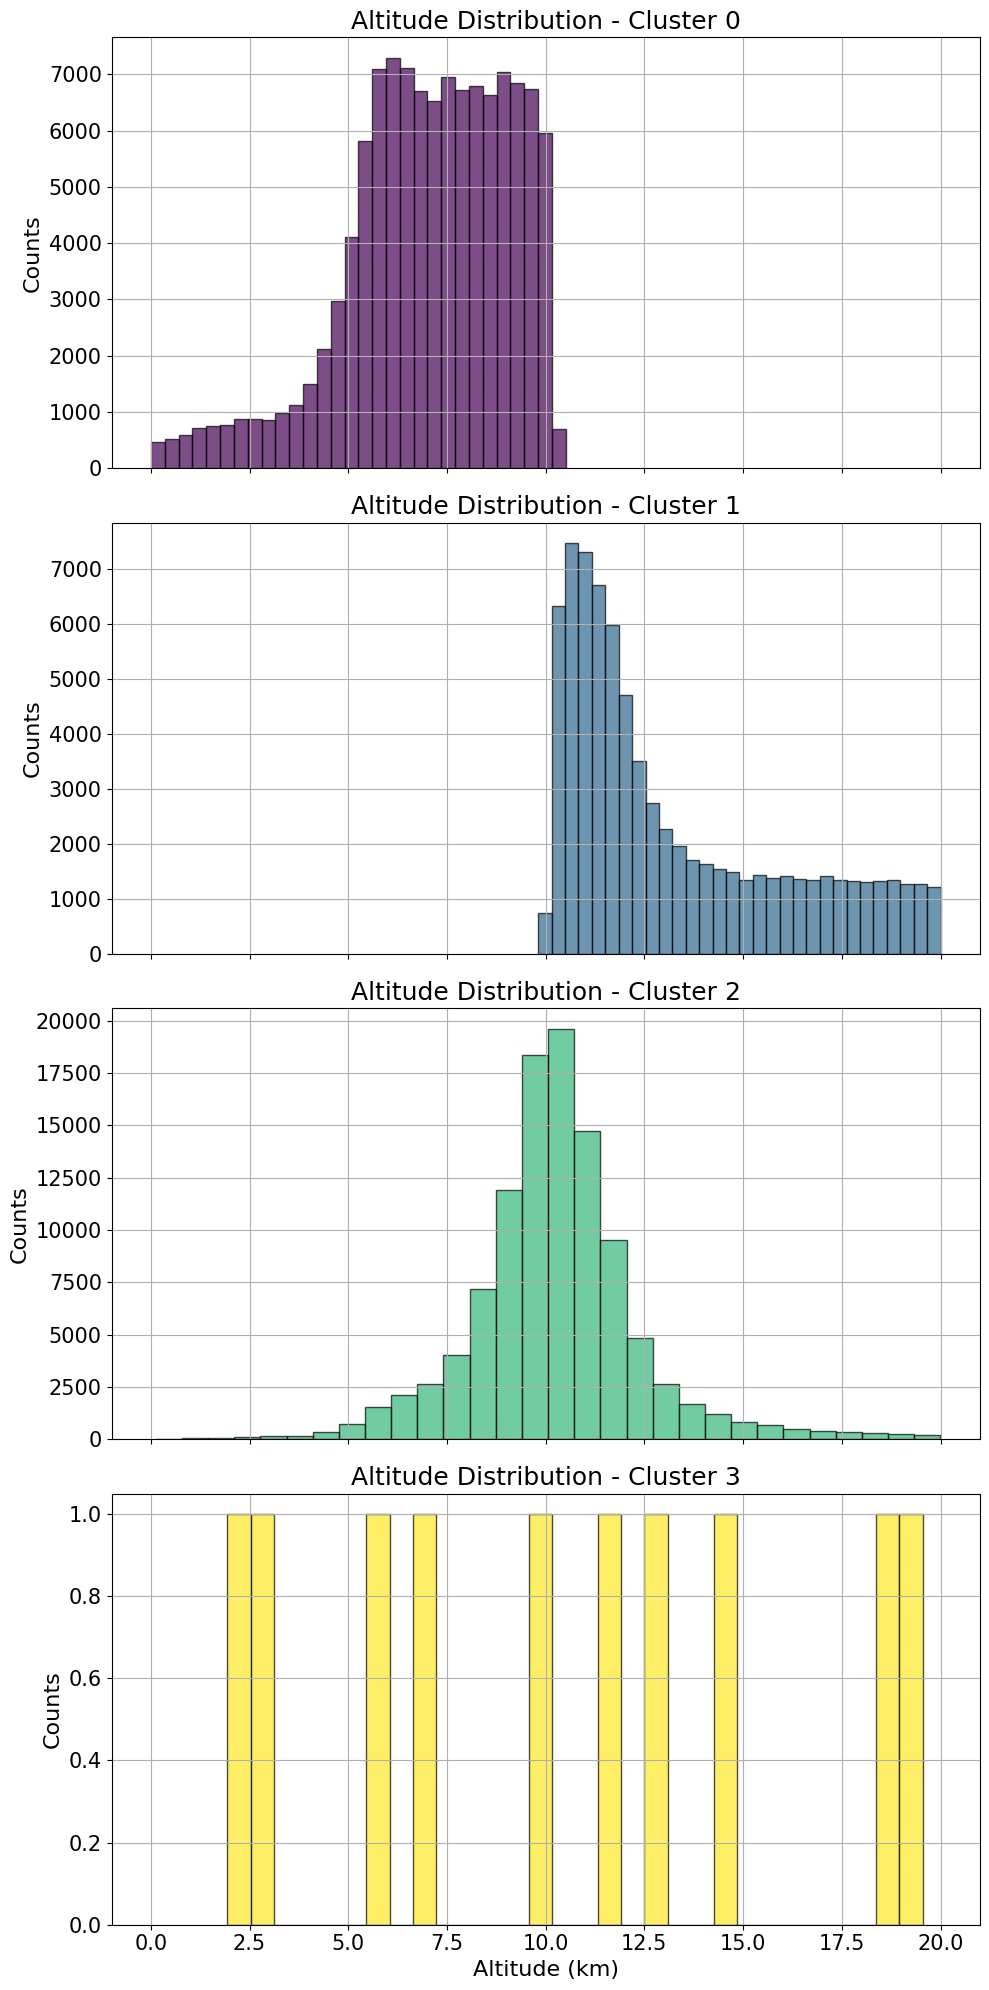

In [ ]:
import matplotlib.pyplot as plt

unique_clusters = dflma['cluster'].unique()
num_clusters = len(unique_clusters)

fig_alt_hist, axs_alt_hist = plt.subplots(num_clusters, 1, figsize=(10, 5 * num_clusters), sharex=True)

# Ensure axs_alt_hist is always an array, even for a single subplot
if num_clusters == 1:
    axs_alt_hist = [axs_alt_hist]

for i, cluster_id in enumerate(sorted(unique_clusters)):
    cluster_data = dflma[dflma['cluster'] == cluster_id]
    axs_alt_hist[i].hist(cluster_data['alt'], bins=30, alpha=0.7, color=plt.cm.viridis(cluster_id / (num_clusters - 1)), edgecolor='black')
    axs_alt_hist[i].set_title(f'Altitude Distribution - Cluster {cluster_id}', size=lblsize + 2)
    axs_alt_hist[i].set_ylabel('Counts', size=lblsize)
    axs_alt_hist[i].tick_params(labelsize=ticksize)
    axs_alt_hist[i].grid(True)

axs_alt_hist[-1].set_xlabel('Altitude (km)', size=lblsize)

plt.tight_layout()
plt.show()

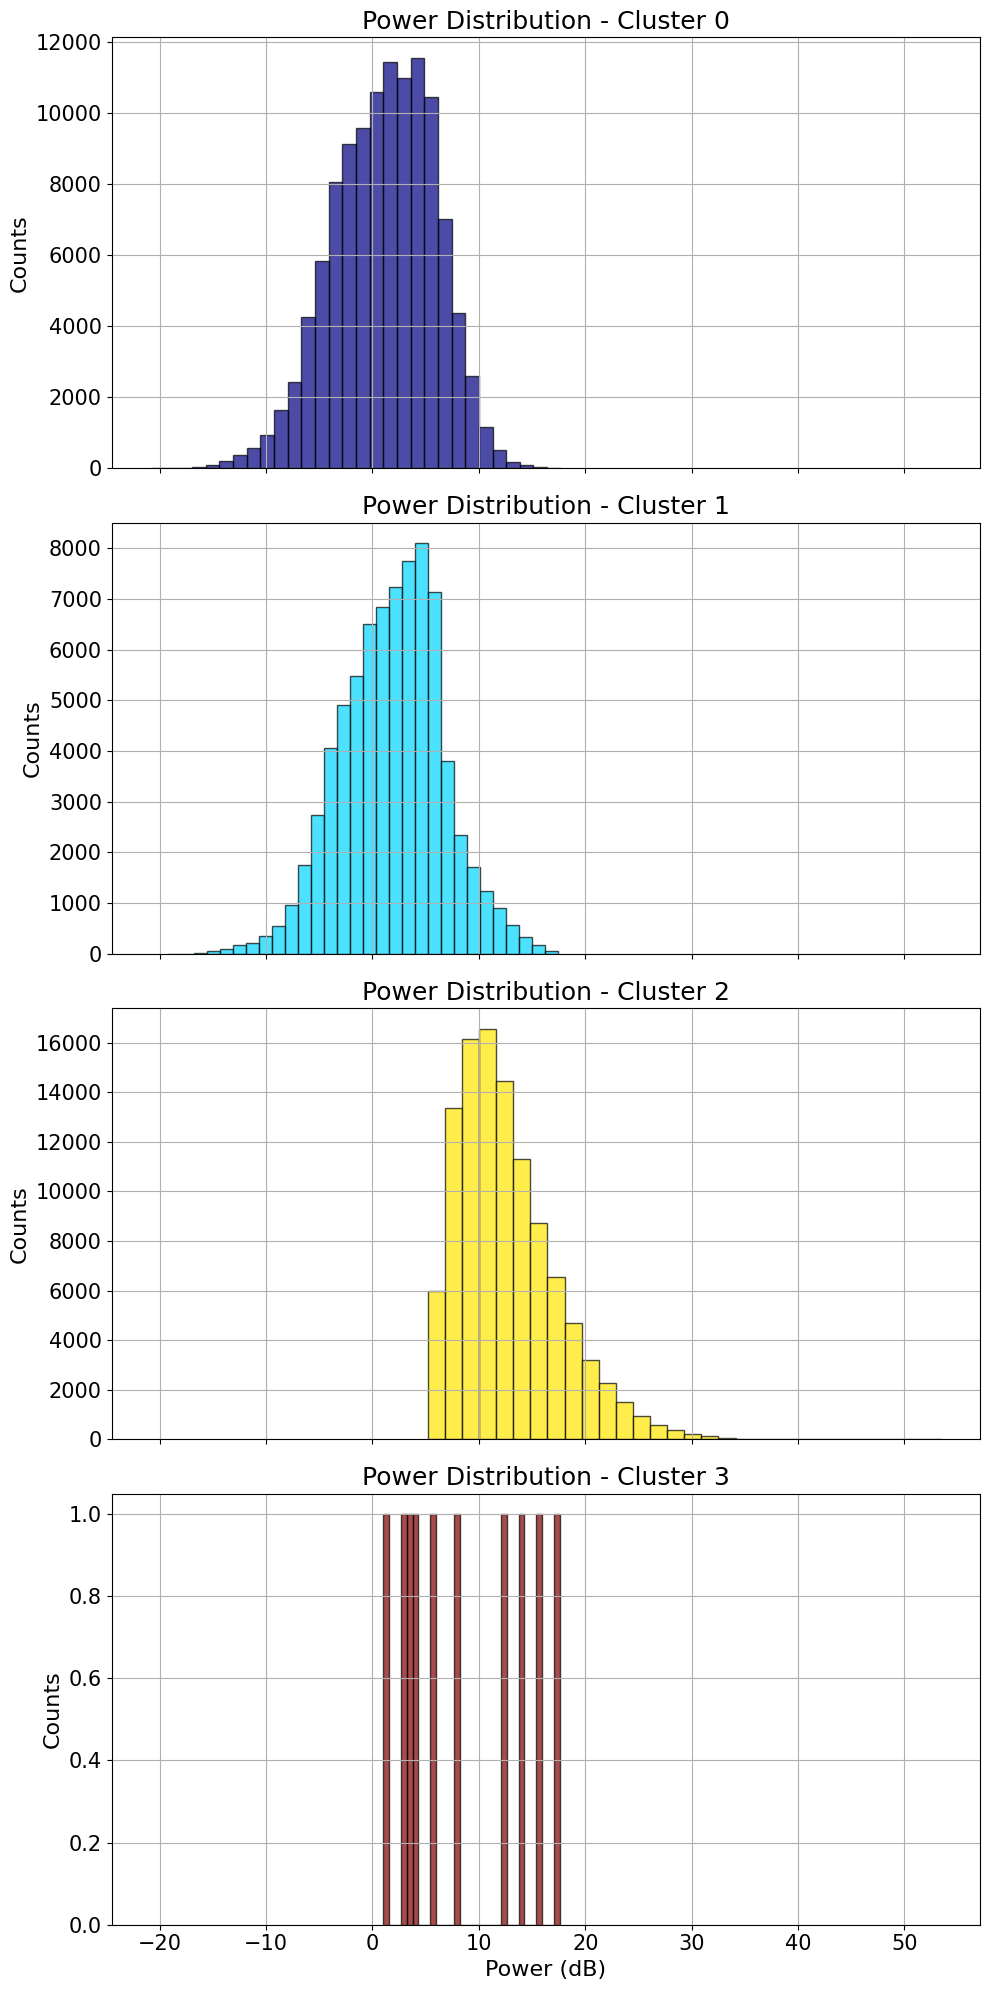

In [ ]:
import matplotlib.pyplot as plt

unique_clusters = dflma['cluster'].unique()
num_clusters = len(unique_clusters)

fig_pw_hist, axs_pw_hist = plt.subplots(num_clusters, 1, figsize=(10, 5 * num_clusters), sharex=True)

# Ensure axs_pw_hist is always an array, even for a single subplot
if num_clusters == 1:
    axs_pw_hist = [axs_pw_hist]

for i, cluster_id in enumerate(sorted(unique_clusters)):
    cluster_data = dflma[dflma['cluster'] == cluster_id]
    axs_pw_hist[i].hist(cluster_data['pw'], bins=30, alpha=0.7, color=plt.cm.jet(cluster_id / (num_clusters - 1)), edgecolor='black')
    axs_pw_hist[i].set_title(f'Power Distribution - Cluster {cluster_id}', size=lblsize + 2)
    axs_pw_hist[i].set_ylabel('Counts', size=lblsize)
    axs_pw_hist[i].tick_params(labelsize=ticksize)
    axs_pw_hist[i].grid(True)

axs_pw_hist[-1].set_xlabel('Power (dB)', size=lblsize)

plt.tight_layout()
plt.show()


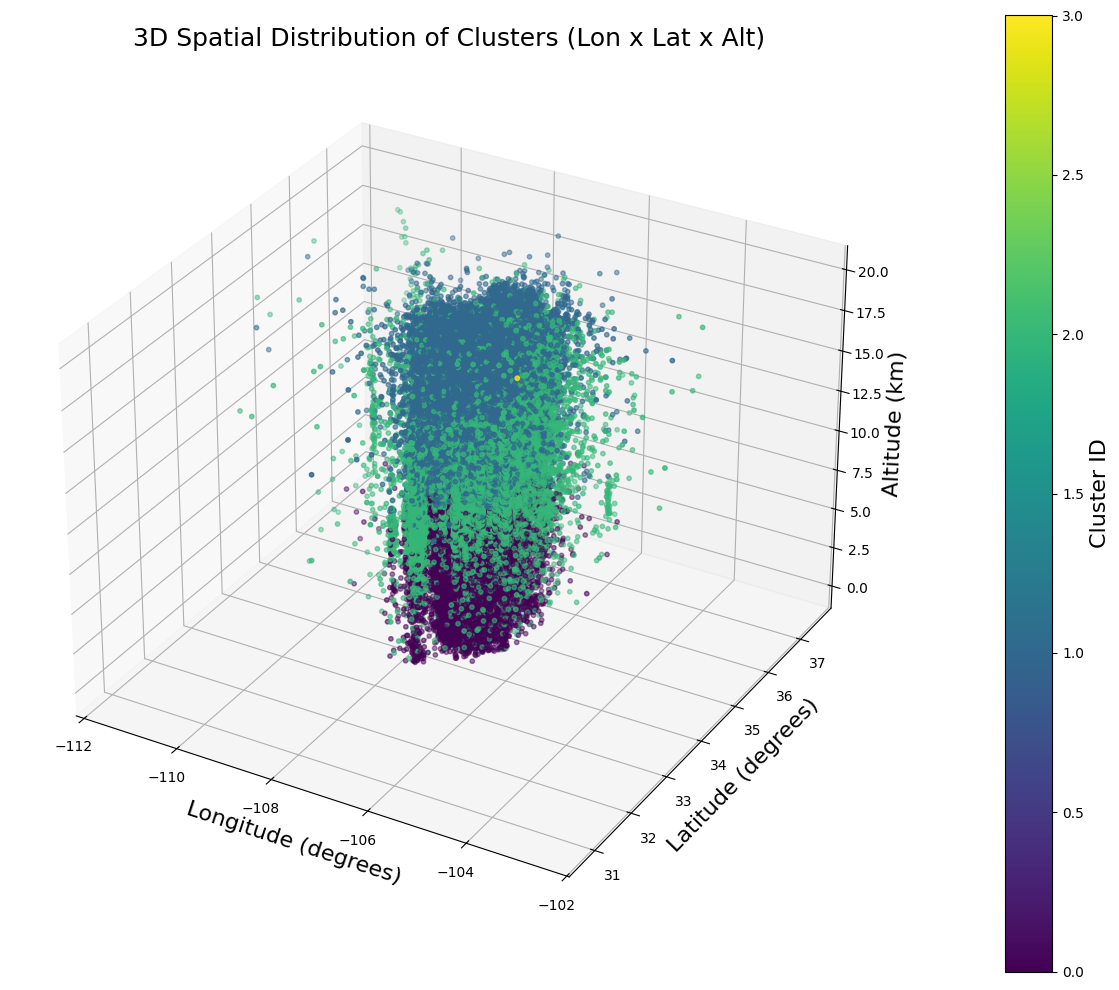

In [ ]:
import matplotlib.pyplot as plt

fig_3d = plt.figure(figsize=(12, 10))
ax_3d = fig_3d.add_subplot(111, projection='3d')

scatter_3d = ax_3d.scatter(dflma['lon'], dflma['lat'], dflma['alt'], c=dflma['cluster'], cmap='viridis', s=10)

ax_3d.set_xlabel('Longitude (degrees)', size=lblsize)
ax_3d.set_ylabel('Latitude (degrees)', size=lblsize)
ax_3d.set_zlabel('Altitude (km)', size=lblsize)
ax_3d.set_title('3D Spatial Distribution of Clusters (Lon x Lat x Alt)', size=lblsize + 2)

cbar_3d = fig_3d.colorbar(scatter_3d, ax=ax_3d, pad=0.1)
cbar_3d.set_label('Cluster ID', size=lblsize)

plt.tight_layout()
plt.show()

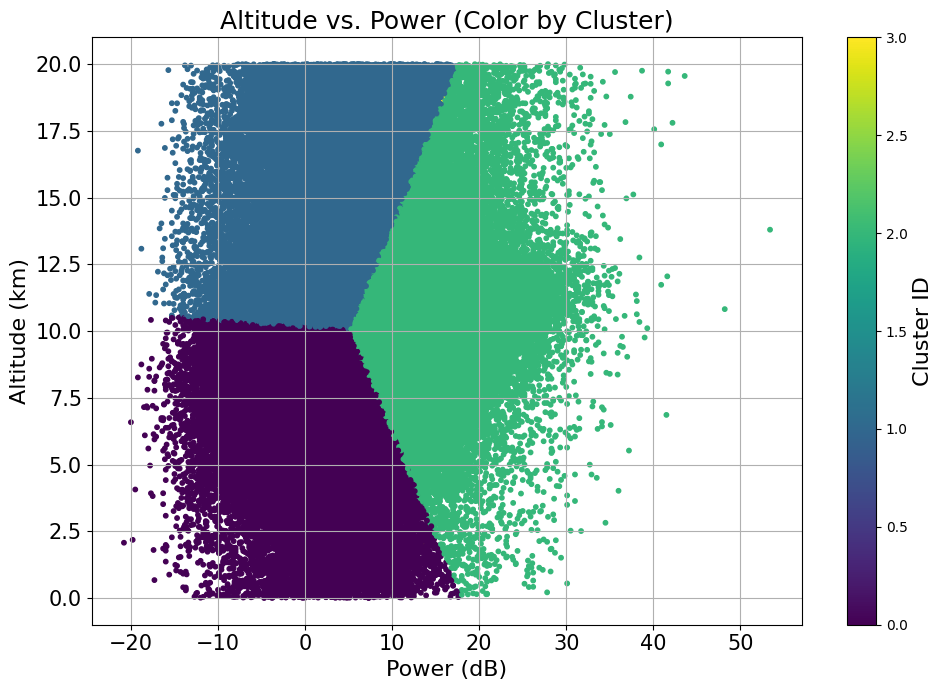

In [ ]:
import matplotlib.pyplot as plt

fig_alt_pw, ax_alt_pw = plt.subplots(figsize=(10, 7))
scatter_alt_pw = ax_alt_pw.scatter(dflma['pw'], dflma['alt'], c=dflma['cluster'], cmap='viridis', s=10)

ax_alt_pw.set_xlabel('Power (dB)', size=lblsize)
ax_alt_pw.set_ylabel('Altitude (km)', size=lblsize)
ax_alt_pw.set_title('Altitude vs. Power (Color by Cluster)', size=lblsize + 2)
ax_alt_pw.tick_params(labelsize=ticksize)
ax_alt_pw.grid(True)

cbar_alt_pw = fig_alt_pw.colorbar(scatter_alt_pw, ax=ax_alt_pw)
cbar_alt_pw.set_label('Cluster ID', size=lblsize)

plt.tight_layout()
plt.show()


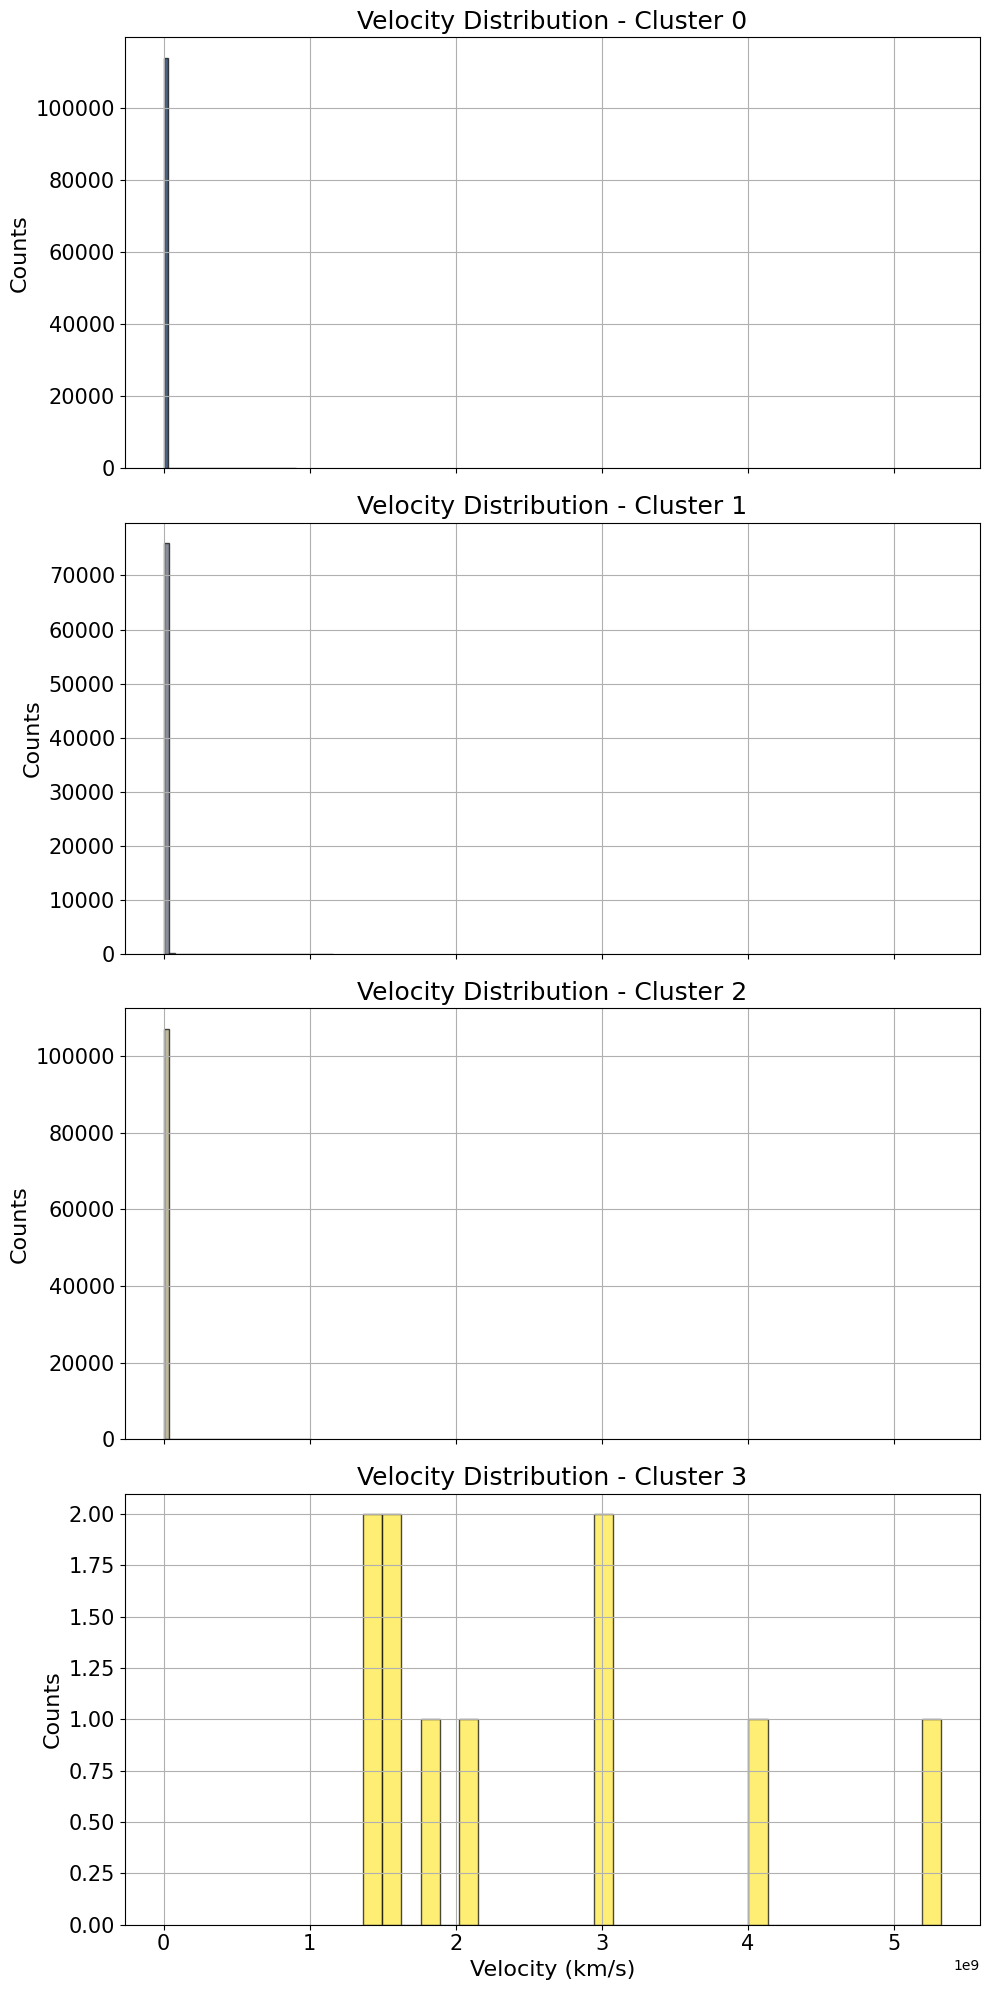

In [ ]:
import matplotlib.pyplot as plt

unique_clusters = dflma['cluster'].unique()
num_clusters = len(unique_clusters)

fig_vel_hist, axs_vel_hist = plt.subplots(num_clusters, 1, figsize=(10, 5 * num_clusters), sharex=True)

# Ensure axs_vel_hist is always an array, even for a single subplot
if num_clusters == 1:
    axs_vel_hist = [axs_vel_hist]

for i, cluster_id in enumerate(sorted(unique_clusters)):
    cluster_data = dflma[dflma['cluster'] == cluster_id]
    axs_vel_hist[i].hist(cluster_data['velocity'], bins=30, alpha=0.7, color=plt.cm.cividis(cluster_id / (num_clusters - 1)), edgecolor='black')
    axs_vel_hist[i].set_title(f'Velocity Distribution - Cluster {cluster_id}', size=lblsize + 2)
    axs_vel_hist[i].set_ylabel('Counts', size=lblsize)
    axs_vel_hist[i].tick_params(labelsize=ticksize)
    axs_vel_hist[i].grid(True)

axs_vel_hist[-1].set_xlabel('Velocity (km/s)', size=lblsize)

plt.tight_layout()
plt.show()

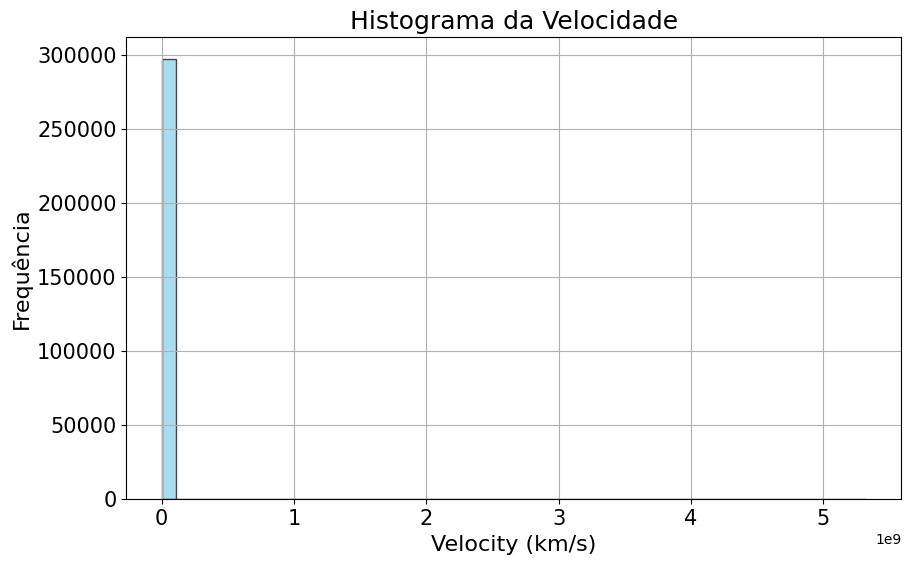

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(dflma['velocity'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Histograma da Velocidade', size=lblsize + 2)
plt.xlabel('Velocity (km/s)', size=lblsize)
plt.ylabel('Frequência', size=lblsize)
plt.tick_params(labelsize=ticksize)
plt.grid(True)
plt.show()